# 🏨 Hotel Cancellation Prediction: Logistic Regression Lab
## Can we predict which bookings will be cancelled before they happen?

---

### The Business Problem

Hotel cancellations are a massive headache for the hospitality industry.  
Consider a hotel with 200 rooms that is fully booked for a Saturday night:

- If **20% of bookings cancel** (a realistic figure), the hotel loses revenue on 40 rooms it could have re-sold.
- If the hotel **overbooks aggressively** and fewer people cancel than expected, it must walk guests to a competitor — destroying customer loyalty.
- You are a data scientist at a fast growing hotel brand and they need a better way to predict cancellations, they have a pretty good size
dataset and would like you to help. If the model works well you get a 10% bonus of all the recovered revenue!  

**A good cancellation-prediction model lets hotels:**
1. **Optimize overbooking** — sell the right number of extra rooms so the hotel fills up even after cancellations.
2.  **Improve staffing** — if 30% of tonight's bookings will cancel, fewer housekeepers and front-desk staff are needed.
3.  **Target at-risk bookings** — reach out proactively with incentives (free breakfast, discount upgrade) to guests who are likely to cancel.

### The Dataset

We are working with the **Hotel Booking Demand** dataset (~119 k real bookings from two Portuguese hotels).  
Our **target variable** is `is_canceled`: `1` if the booking was cancelled, `0` if the guest actually showed up.

### What You Will Build

| Model | Key idea |
|-------|----------|
| **Model 1** | Baseline pipeline — default solver (`lbfgs`), one-hot encoding + standard scaling |
| **Model 2** | Solver exploration — try using different solvers and see if the model improves |
| **Model 3** | Class-weighted logistic regression + cross-validation to handle imbalanced labels |



---
## 1 · Setup & Data Loading

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, RocCurveDisplay,
    classification_report
)

sns.set_style('whitegrid')

In [35]:
# load in the data
df = pd.read_csv('hotels.csv')

---
## 2 · Exploratory Data Analysis

Before building any model we need to **understand our data**.  


In [36]:
# Print out summary stats and basic info on the dataset, what trends do you notice?

# Investigate the data itself
df.info()
df.describe()

# I notice large amounts of outliers where many of the columns are concentrated near zero, but the maximum is way higher than the mean.
# Company is a mostly empty column
# Most columns have entries, and the only other column with a lot of missing data is agent
# There is sporadic missing data, and so I choose to get rid of them as it only represents at most less than 1 percent of any one column.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [37]:
# Calculate prevalence of the target value, how hard of problem is this going to be?

print("Prevalence is: "+str(df[df["is_canceled"] == True]["is_canceled"].count()/df["is_canceled"].count()))

# The problem will be moderately difficult as we need to be better than chance, and better than 0.37% accuracy when predicting whether someone will cancel or not.

Prevalence is: 0.37041628277075134


---
## 3 · Feature Engineering - Preparation

Before building any model we need to **understand our data**. 

In [38]:
# Check for missing data and drop features with too many missing values, there are some.
 
# Seemingly Company has so many missing entries so I will remove it

df=df.drop(columns=["company", "agent"])
df=df.dropna()

In [39]:
# There are two other features that need to be dropped because they directly leak the target variable.
# Another way to say this is they represent leakage in the dataset.

df=df.drop(columns=["reservation_status","reservation_status_date"])

---
### Feature groups, see step 4 in the example (i think it goes 1,2,4 I deleted 3 and didn't change the numbering)

Create lists for the **numerical** and **categorical** so we can apply the right transformations to each group inside a `ColumnTransformer`.

> **Why scale numerics?** Logistic regression uses gradient descent internally.  
> Features on very different scales (e.g. `lead_time` 0–737 vs `adults` 0–4) slow convergence.  
> `StandardScaler` fixes this by converting each feature to mean=0, std=1.

> **Why one-hot encode categoricals?** Logistic regression can't handle strings.  
> One-hot encoding converts each category into its own binary (0/1) column.

Keep in mind that we want to use the pipeline package to handle this preprocessing so create lists of names of numeric and category then pass them into the pipeline, not necessarily creating different dataframes. 



In [40]:
# Prepare for the pipeline make sure to do so for both **numerical** and **categorical**. 
# Generate dataframe for the features and target variable, X and y.

# Create the separation in numeric and categorical columns and label them as such
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Drop target variable
numeric_cols.remove("is_canceled")

# print the columns to check
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Standard scales numeric and one hot encodes categorical
# I don't use this really, but I made it beforehand, so it is here now :)
preprocessorStandard = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

# X and y are defined, with the canceled dropped for X and saved in y.
y = df["is_canceled"]
X = df.drop(columns=["is_canceled"])

Numeric columns: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


In [41]:
# Train / test split — 80/20, stratified so class ratios are preserved 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=df["is_canceled"])

---
## 4 · Model Building and Evaluation

Now we are going to build our **model pipeline** and use the transformers

---
Model 1 — Baseline Logistic Regression

Our first pipeline is intentionally **simple**.  
The goal is to establish a baseline score we can try to beat later.
Transformer categorical using one-hot encoding and numerical using the MinMaxscaler()

X_raw  →  ColumnTransformer  →  LogisticRegression(solver='lbfgs')
           (scale + encode)


**`lbfgs`** (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is sklearn's default solver, like we talked about in class

                 precision    recall  f1-score   support

is_not_canceled       0.81      0.91      0.86     14949
    is_canceled       0.80      0.65      0.72      8831

       accuracy                           0.81     23780
      macro avg       0.81      0.78      0.79     23780
   weighted avg       0.81      0.81      0.81     23780



c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


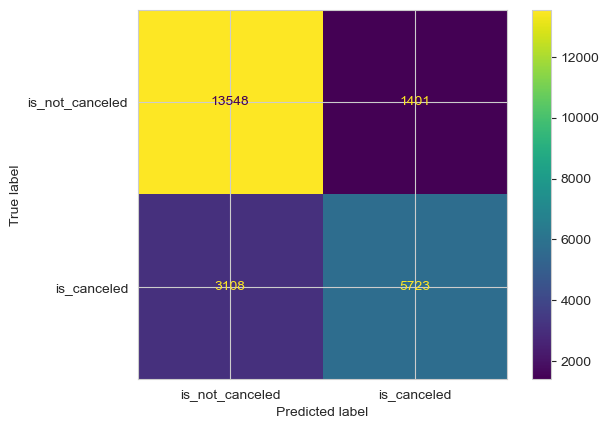

In [42]:
# Preprocessor if I were to use a min max scalar for the numerics
preprocessorMinMax = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

# Pipeline that feeds that updated and transformed data into the logistical regression model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessorMinMax),
    ('classifier', LogisticRegression(max_iter=100, solver="lbfgs"))
])

# Train the model
pipeline.fit(X_train, y_train)

# Predict using the model on test data
y_predicted = pipeline.predict(X_test)

# See the classification report which gives us precision, recall, and f1-score
print(classification_report(y_test, y_predicted, target_names=["is_not_canceled", "is_canceled"]))

# See the confusion matrix created, and plotted 
cm=confusion_matrix(y_test, y_predicted)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["is_not_canceled", "is_canceled"]).plot()

---
 Model 1 Evaluation: Now that the model is build lets evaluate the model using confusion matrix and ROC/AUC. Give the goal of your assignment how well does the model work?

The Confusion Matrix Will Be Important Evaluation Tool

For a hotel-cancellation problem the four cells of the confusion matrix have real business meaning:

| | Predicted: Kept | Predicted: Cancelled |
|---|---|---|
| **Actual: Kept** |  **True Negative (TN)** — correctly identified loyal guest |  **False Positive (FP)** — wrongly flagged a loyal guest as a canceller |
| **Actual: Cancelled** |  **False Negative (FN)** — missed a cancellation (costly!) |  **True Positive (TP)** — correctly predicted a cancellation |

**Business impact:**
- **False Negatives** are expensive — we didn't anticipate the cancellation, so we can't fill the room.
- **False Positives** are annoying but cheaper — we might over-staff or over-book slightly.

---
## 5 · Model 2 — Exploring Different Solvers 

- Adjust your model object in the pipeline then evaluate again using confusion matrix and ROC/AUC. Make sure to eval on the test set. You should create a model_2_pipe, use much of the same code but create a new pipeline for each model

Sklearn's `LogisticRegression` supports several **solvers** (optimisation algorithms) and  
**regularisation strategies** controlled by `l1_ratio` and `C`.

| Solver | Best for |
|--------|----------|
| `lbfgs` | Default; works well on most datasets (L2 regularisation) |
| `liblinear` | Smaller datasets; supports L1 via `l1_ratio=1` |
| `saga` | Large datasets; supports L1, L2, and ElasticNet |


Did the model improve based on the various solvers?



c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


                 precision    recall  f1-score   support

is_not_canceled       0.81      0.91      0.86     14949
    is_canceled       0.80      0.65      0.72      8831

       accuracy                           0.81     23780
      macro avg       0.81      0.78      0.79     23780
   weighted avg       0.81      0.81      0.80     23780

                 precision    recall  f1-score   support

is_not_canceled       0.82      0.91      0.86     14949
    is_canceled       0.81      0.66      0.72      8831

       accuracy                           0.82     23780
      macro avg       0.81      0.78      0.79     23780
   weighted avg       0.81      0.82      0.81     23780



c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


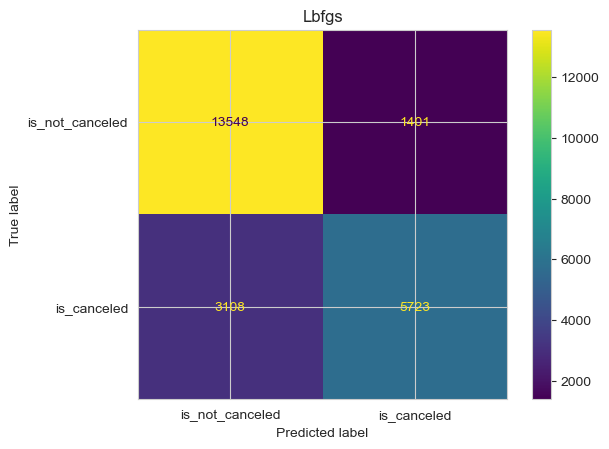

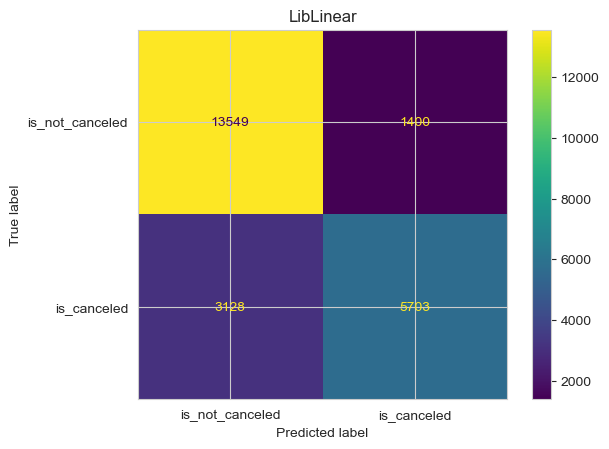

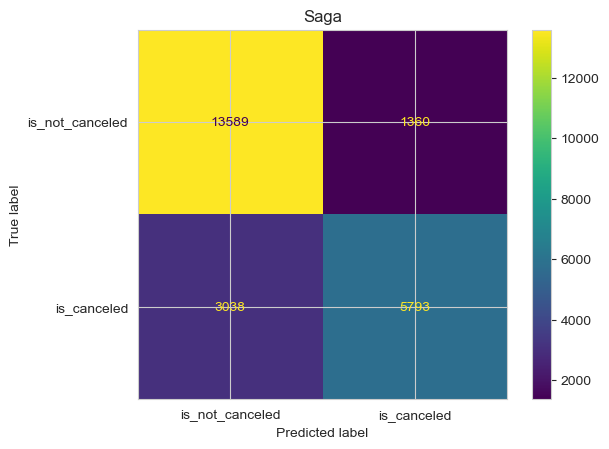

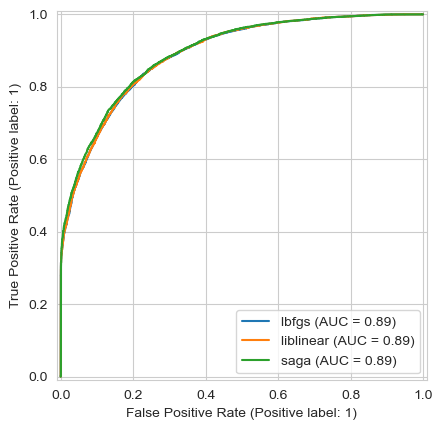

In [43]:
# Preprocessor if I were to use a min max scalar for the numerics
preprocessorMinMax = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

# Pipeline that feeds that updated and transformed data into the logistical regression model
pipeline_liblin = Pipeline(steps=[
    ('preprocessor', preprocessorMinMax),
    ('classifier', LogisticRegression(max_iter=100, solver="liblinear", l1_ratio=1))
])

# Pipeline that feeds that updated and transformed data into the logistical regression model
pipeline_saga = Pipeline(steps=[
    ('preprocessor', preprocessorMinMax),
    ('classifier', LogisticRegression(max_iter=100, solver="saga", penalty="l1"))
])

# Train the model for liblin
pipeline_liblin.fit(X_train, y_train)
# Train the model for saga
pipeline_saga.fit(X_train, y_train)

# Predict using the liblin model on test data
y_predicted_liblin = pipeline_liblin.predict(X_test)
# Predict using the saga model on test data
y_predicted_saga = pipeline_saga.predict(X_test)

# See the classification report which gives us precision, recall, and f1-score for the liblin model
print(classification_report(y_test, y_predicted_liblin, target_names=["is_not_canceled", "is_canceled"]))
# See the classification report which gives us precision, recall, and f1-score for the saga model
print(classification_report(y_test, y_predicted_saga, target_names=["is_not_canceled", "is_canceled"]))

# See the confusion matrix created, and plotted for lbfgs model (Seen in Step 4 before, but now in comparison to the others)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["is_not_canceled", "is_canceled"]).plot()
plt.title("Lbfgs")
# See the confusion matrix created, and plotted for liblin model
cmlib=confusion_matrix(y_test, y_predicted_liblin)
ConfusionMatrixDisplay(confusion_matrix=cmlib, display_labels=["is_not_canceled", "is_canceled"]).plot()
plt.title("LibLinear")
# See the confusion matrix created, and plotted for saga model
cmsaga=confusion_matrix(y_test, y_predicted_saga)
ConfusionMatrixDisplay(confusion_matrix=cmsaga, display_labels=["is_not_canceled", "is_canceled"]).plot()
plt.title("Saga")

# I create a plot to hold the Three AUC plots
fig, ax = plt.subplots()

# Get the probability of each prediction for all three models so far as it is a good way to make an ROC Curve Display
y_prob_lbfgs = pipeline.predict_proba(X_test)[:, 1]
y_prob_liblin = pipeline_liblin.predict_proba(X_test)[:, 1]
y_prob_saga = pipeline_saga.predict_proba(X_test)[:, 1]

# Use said probability to create the roc curves for both models and our original model(lbfgs)
RocCurveDisplay.from_predictions(y_test, y_prob_lbfgs, name="lbfgs", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_liblin, name="liblinear", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_saga, name="saga", ax=ax)
# These all overlap implying that the quality is pretty consistent between them. A good future test might be to test them beyond just one threshold, even with different regularization methods.

plt.show()

---
## 6 · Model 3 — Balanced Class Weights + Cross-Validation

Build a final model (pipe_3) with a balanced class weight and use cross validation. As a reminder cv happens on the fit process not as part of the pipeline and we need to build our CV object, similar to the model object. . 

Use the example shown in class to see how to apply cross validation, balanced weight is a argument in the logreg function that you just need to apply as seen below. 

### The Class Imbalance Problem

Our dataset has ~63% non-cancellations and ~37% cancellations.  
A lazy model could achieve 63% accuracy by *always* predicting "Kept"!  
We saw that Models 1 and 2 sometimes struggled with **recall on the cancelled class**.

### Solution: `class_weight='balanced'`

Setting `class_weight='balanced'` tells sklearn to automatically weight the training samples  
so that the minority class (cancellations) gets more attention during training.

Specifically, each class gets weight = `n_samples / (n_classes × n_samples_in_class)`.

### Solution: Cross-Validation

Instead of a single train/test split (which can be lucky or unlucky),  
**k-fold cross-validation** trains and evaluates the model on `k` different splits  
and reports the average — giving a much more reliable estimate of real-world performance.

```
Fold 1: [train | train | train | train | VAL ]
Fold 2: [train | train | train | VAL  | train]
Fold 3: [train | train | VAL  | train | train]
...and so on
```

---

### Experiments

- Change the number of folds from `5` to `10` — does the mean AUC change much?
- Try removing `class_weight='balanced'` — what happens to recall on the cancelled class?

In [44]:
# Define a new Pipeline that now has max iter 500, it's ibfgs(because all the models performed similarily and this was fastest), and the classes are balanced
pipeline_cv = Pipeline(steps=[
    ('preprocessor', preprocessorMinMax),
    ('classifier', LogisticRegression(max_iter=500, solver="lbfgs", penalty="l2", class_weight='balanced'))
])

In [45]:
# k fold = 5
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Then scores for AUC, F1, Accuracy, and Recall are calculated
cv_auc5  = cross_val_score(pipeline_cv, X, y, cv=cv5, scoring='roc_auc')
cv_f1_5   = cross_val_score(pipeline_cv, X, y, cv=cv5, scoring='f1')
cv_scores5 = cross_val_score(pipeline_cv, X, y, cv=cv5, scoring='accuracy')
cv_recall5 = cross_val_score(pipeline_cv, X, y, cv=cv5, scoring='recall')

c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 5, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\

In [46]:
print("K-fold = 5 and class_weight=balanced")
print("AUC Mean: "+str(np.mean(cv_auc5)))
print("F1 Mean: "+str(np.mean(cv_f1_5)))
print("Accuracy Mean: "+str(np.mean(cv_scores5)))
print("Recall Mean: "+str(np.mean(cv_recall5)))

K-fold = 5 and class_weight=balanced
AUC Mean: 0.8933398569560496
F1 Mean: 0.749501771562419
Accuracy Mean: 0.806943787570653
Recall Mean: 0.7777501396873184


In [47]:
# k fold = 10
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Then scores for AUC, F1, Accuracy, and Recall are calculated
cv_auc10  = cross_val_score(pipeline_cv, X, y, cv=cv10, scoring='roc_auc')
cv_f1_10   = cross_val_score(pipeline_cv, X, y, cv=cv10, scoring='f1')
cv_scores10 = cross_val_score(pipeline_cv, X, y, cv=cv10, scoring='accuracy')
cv_recall10 = cross_val_score(pipeline_cv, X, y, cv=cv10, scoring='recall')

c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\

In [48]:
print("K-fold = 10 and class_weight=balanced")
print("AUC Mean: "+str(np.mean(cv_auc10)))
print("F1 Mean: "+str(np.mean(cv_f1_10)))
print("Accuracy Mean: "+str(np.mean(cv_scores10)))
print("Recall Mean: "+str(np.mean(cv_recall10)))

K-fold = 10 and class_weight=balanced
AUC Mean: 0.8936026082801984
F1 Mean: 0.7500529140694561
Accuracy Mean: 0.8073643403614073
Recall Mean: 0.7783390163638452


In [49]:
# class weight not balanced? what happens to the canceled class?
pipeline_cv_nb = Pipeline(steps=[
    ('preprocessor', preprocessorMinMax),
    ('classifier', LogisticRegression(max_iter=100, solver="lbfgs", penalty="l2", class_weight=None))
])

# Then scores for AUC, F1, Accuracy, and Recall are calculated
cv_aucnb  = cross_val_score(pipeline_cv_nb, X, y, cv=cv10, scoring='roc_auc')
cv_f1_nb   = cross_val_score(pipeline_cv_nb, X, y, cv=cv10, scoring='f1')
cv_scoresnb = cross_val_score(pipeline_cv_nb, X, y, cv=cv10, scoring='accuracy')
cv_recallnb = cross_val_score(pipeline_cv_nb, X, y, cv=cv10, scoring='recall')

c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteratio

In [50]:
print("K-fold = 10 and class_weight=not balanced")
print("AUC Mean: "+str(np.mean(cv_aucnb)))
print("F1 Mean: "+str(np.mean(cv_f1_nb)))
print("Accuracy Mean: "+str(np.mean(cv_scoresnb)))
print("Recall Mean: "+str(np.mean(cv_recallnb)))

K-fold = 10 and class_weight=not balanced
AUC Mean: 0.8922154198753933
F1 Mean: 0.7207835343796826
Accuracy Mean: 0.8120153478832552
Recall Mean: 0.6533872503159518


Change the number of folds from `5` to `10` — does the mean AUC change much?

No the AUC didn't change all too much when k-folds increased from 5 to 10, it slightly improved but not to significant degree since the underlying model didn't really change.

Try removing `class_weight='balanced'` — what happens to recall on the cancelled class?

When we removed class_weight=balanced, the Recall sharply declines while accuracy sharply increased. This seems to be since our data is heavily unbalanced and is biased towards training on the majority class, class_weight helps to improve recall for the minority class(which is "is_canceled"), but hurts overall accuracy in doing so.

---
## 07 · Summary & Reflection

### What We Learned

**Model Performance**
- Which model worked best and why do you think that is the case? Write a short recommendation to your boss on how to proceed (1 paragraph)

### Challenge Extensions - extra 5 points for each

If you want to push further:

1. **Tune `C`** using `GridSearchCV` over the range `[0.001, 0.01, 0.1, 1, 10, 100]`.
2. **Engineer new features** — e.g. `total_nights = stays_in_weekend_nights + stays_in_week_nights`.
3. **Try a different model** — replace `LogisticRegression` in the pipeline with `RandomForestClassifier` or `GradientBoostingClassifier`. Does AUC improve? or maybe kNN
4. **Interpret coefficients** — given that the variables have been standardized create a horizontal bar chart showing
the rankings of the coeficients 

---

Which model worked best and why do you think that is the case? Write a short recommendation to your boss on how to proceed (1 paragraph)?

Dear Boss,

After testing out many different models, many performed very similarly, but took drastically shorter amounts of time. A time efficient, yet effective model seemed to be the lbfgs model. This ran quick and had a very similar performance to the others. Since most results are people not canceling our hotel service, we needed to account for that, and we found it to be accurate at predicting whether someone would cancel our service correctly when we used our last model that balanced the class weights. We got better consistent results as well when splitting the data up into smaller sets, when doing that our model was sure to have a diverse and representative selection from our dataset. To use less technical speech, I would say it helped make sure we were taking in the entire picture when choosing our model instead of just focusing on a certain fraction of the data. We should use this model, currently called pipeline_cv, to help us get a better idea whether a customer may later cancel their reservation, helping us plan for that scenario and maybe offer said room to someone else, expecting it to be taken and thus maximizing profit regardless.

1. **Tune `C`** using `GridSearchCV` over the range `[0.001, 0.01, 0.1, 1, 10, 100]`.

In [51]:
from sklearn.model_selection import GridSearchCV

# The range of values for C
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100] # Has to be called classifier__C because of how Logisitical Regression's function is defined
}

# Creating the grid search
grid_search = GridSearchCV(estimator=pipeline_cv,
    param_grid=param_grid,
    cv=5, # So not too many
    scoring='accuracy')

# Training the model
grid_search.fit(X_train, y_train)

# Best parameter printed out
print("Best C:", grid_search.best_params_['classifier__C'])

# Best score just for reference
print("Best CV Score:", grid_search.best_score_)

# This is the best model
best_model = grid_search.best_estimator_
print(best_model)

c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-p

Best C: 100
Best CV Score: 0.8111188656934125
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellations',
                                                   'previous_bookings_not_canceled',
                                

3. **Try a different model** — replace `LogisticRegression` in the pipeline with `RandomForestClassifier` or `GradientBoostingClassifier`. Does AUC improve? or maybe kNN

In [52]:
# Pipeline with RFC
pipeline_RFC = Pipeline(steps=[
    ('preprocessor', preprocessorMinMax),
    ('classifier', RandomForestClassifier(n_jobs=-1))
])

# Then scores for AUC is calculated to see if it improves
RFC_auc  = cross_val_score(pipeline_RFC, X, y, cv=5, scoring='roc_auc')
print("AUC Mean: "+str(np.mean(RFC_auc))) 
# AUC = 0.5621052974930094 Was the value I gathered, so it performed much worse
# However, our hyperparameters are different, and that definitely plays a role

c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


AUC Mean: 0.5542971323535995


c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [53]:
# Pipeline with KNN
from sklearn.neighbors import KNeighborsClassifier
pipeline_KNN = Pipeline(steps=[
    ('preprocessor', preprocessorMinMax),
    ('classifier', KNeighborsClassifier(n_jobs=-1))
])

# Then scores for AUC is calculated to see if it improves
KNN_auc  = cross_val_score(pipeline_RFC, X, y, cv=5, scoring='roc_auc')

c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\CybCy\anaconda3\envs\pytorch\Lib\

In [54]:
print("AUC Mean: "+str(np.mean(KNN_auc)))

# AUC = 0.5489811157481882, was what I got, so it performed worse than the earlier models by a lot, some of which were around 0.89.
# However, our hyperparameters are different, and that definitely plays a role here as it did in the RFC example

AUC Mean: 0.5595942586741407
